# Single-POV Golf Swing Reconstruction — Model Evaluation Baseline

**Purpose.** This notebook answers two questions for tomorrow's team
discussion:

1. **What's the best way to evaluate this app and the models inside it?**
   We define a rigorous evaluation framework with both reference-based
   (GolfDB swing-event labels) and reference-free (physics-based) metrics
   suitable for golf-specific pose estimation.
2. **Which off-the-shelf model is the strongest 2D baseline, without
   fine-tuning?** We benchmark seven candidates on the full GolfDB
   dataset under that framework and produce a leaderboard.

**Relation to coworker's `GolfDB_EDA.ipynb`.** Coworker ran MediaPipe Pose
Heavy on a single sample video. This notebook (a) recreates that pipeline
as one of the contenders, (b) expands to all 1,400 labeled GolfDB clips,
and (c) adds five other models plus quantitative metrics. The original
notebook's pipeline is reused as the `MediaPipeAdapter` in
`adapters/mediapipe_adapter.py`.

**Scope this run.** Off-the-shelf inference only — no fine-tuning, no
domain adaptation, no manual prompt engineering. We're scoping which
backbone the team should invest in.


---

## §2 Setup and GolfDB exploration

Before we can benchmark, we need to (a) understand what's in GolfDB,
(b) choose a sane eval subset, and (c) get the label coordinate system
right.

**Coordinate system gotcha.** GolfDB's `events` column stores 10 frame
indices: a buffer frame, the 8 swing events, and another buffer. The
indices reference the *original YouTube source video*. But the clips
we run inference on (`Data/videos_160/`) were re-cropped to span only
`events[0] .. events[-1]` — so frame 0 of our clip corresponds to
`events[0]` of the YouTube original. Every event-based metric (PCE)
needs to subtract `events[0]` to translate into clip-local frames.


In [1]:
import os, sys, time, json, warnings
from pathlib import Path

# Quiet TF / MediaPipe / HF noise
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Scripts' else Path.cwd()
DATA_DIR     = PROJECT_ROOT / 'Data'
VIDEO_DIR    = DATA_DIR / 'videos_160'
GOLFDB_DIR   = PROJECT_ROOT / 'golfdb'
MODEL_DIR    = PROJECT_ROOT / 'Models'
CACHE_DIR    = DATA_DIR / 'eval_runs'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT / 'Scripts'))

sns.set_theme(style='whitegrid', context='notebook')
print(f'Project root  : {PROJECT_ROOT}')
print(f'Videos at     : {VIDEO_DIR} ({len(list(VIDEO_DIR.glob("*.mp4")))} clips)')
print(f'GolfDB labels : {GOLFDB_DIR / "golfDB.pkl"}')

# Quick status of cached benchmark runs (what's been processed already)
print('\n=== current benchmark cache ===')
if CACHE_DIR.exists():
    for d in sorted(CACHE_DIR.iterdir()):
        if d.is_dir():
            n_clips = len(list(d.glob('*.parquet')))
            print(f'  {d.name:25s} {n_clips:>5} clips')
metrics_parq = DATA_DIR / 'all_metrics.parquet'
if metrics_parq.exists():
    mtime = pd.Timestamp(metrics_parq.stat().st_mtime, unit='s')
    print(f'\n  all_metrics.parquet last refreshed: {mtime}')
    print(f'  (run `python Scripts/compute_metrics.py` from project root to refresh)')
else:
    print('\n  all_metrics.parquet not yet built. Run `python Scripts/compute_metrics.py` after a benchmark run.')


Project root  : C:\dev\golf-capstone
Videos at     : C:\dev\golf-capstone\Data\videos_160 (1400 clips)
GolfDB labels : C:\dev\golf-capstone\golfdb\golfDB.pkl

=== current benchmark cache ===
  mediapipe_heavy            1400 clips
  mediapipe_lite             1400 clips
  movenet_lightning          1400 clips
  movenet_thunder            1400 clips
  vitpose_base               1400 clips
  yolov8m_pose               1400 clips
  yolov8n_pose               1400 clips

  all_metrics.parquet last refreshed: 2026-05-23 16:37:46.395615578
  (run `python Scripts/compute_metrics.py` from project root to refresh)


In [2]:
df = pd.read_pickle(GOLFDB_DIR / 'golfDB.pkl')
print(f'{len(df):,} labeled clips')
print()
print('Columns:', list(df.columns))
df.head()


1,400 labeled clips

Columns: ['id', 'youtube_id', 'player', 'sex', 'club', 'view', 'slow', 'events', 'bbox', 'split']


,id,youtube_id,player,sex,club,view,slow,events,bbox,split
0,0,f1BWA5F87Jc,SANDRA GAL,f,driver,down-the-line,0,"[408, 455, 473, 476, 490, 495, 498, 501, 514, ...","[0.09765625000000001, 0.006944444444444444, 0....",3
1,1,f1BWA5F87Jc,SANDRA GAL,f,driver,down-the-line,1,"[814, 854, 917, 931, 988, 1006, 1019, 1030, 10...","[0.039062500000000014, 0.0006944444444444445, ...",3
2,2,tA1iotgtMyc,CHRIS DIMARCO,m,driver,down-the-line,0,"[521, 659, 678, 683, 692, 696, 698, 701, 715, ...","[0.165625, 0.0006944444444444445, 0.48359375, ...",3
3,3,tA1iotgtMyc,CHRIS DIMARCO,m,driver,down-the-line,1,"[1106, 1190, 1244, 1264, 1300, 1313, 1324, 133...","[0.18515625, 0.0006944444444444445, 0.465625, ...",3
4,4,wDCKLePrwHA,BROOKE HENDERSON,f,driver,down-the-line,0,"[157, 170, 183, 188, 197, 201, 205, 207, 220, ...","[0.11015625, 0.0006944444444444445, 0.4984375,...",3


### 2.1 Coverage

GolfDB has 1,400 labeled clips drawn from 580 unique YouTube source videos
across 246 unique golfers. The 4 splits (350 clips each) form a 4-fold CV
arrangement; for this benchmark we don't need the splits since we aren't
training.


In [3]:
print('Unique YouTube sources :', df['youtube_id'].nunique())
print('Unique golfers         :', df['player'].nunique())
print('Clips per split        :', df['split'].value_counts().sort_index().to_dict())


Unique YouTube sources : 580
Unique golfers         : 246
Clips per split        : {1: 350, 2: 350, 3: 350, 4: 350}


### 2.2 Stratification dimensions

The dimensions that matter for evaluating a single-POV pose model:

- **view** — face-on / down-the-line / other. Pose models behave very
  differently on these (face-on: limbs occlude each other; down-the-line:
  the swing plane runs into/away from camera).
- **slow** — slow-motion vs. real-time. Slow-mo gives more frames per
  motion phase, so jitter metrics will look artificially better.
- **sex / club** — body proportions and swing style vary; useful for
  fairness checks.


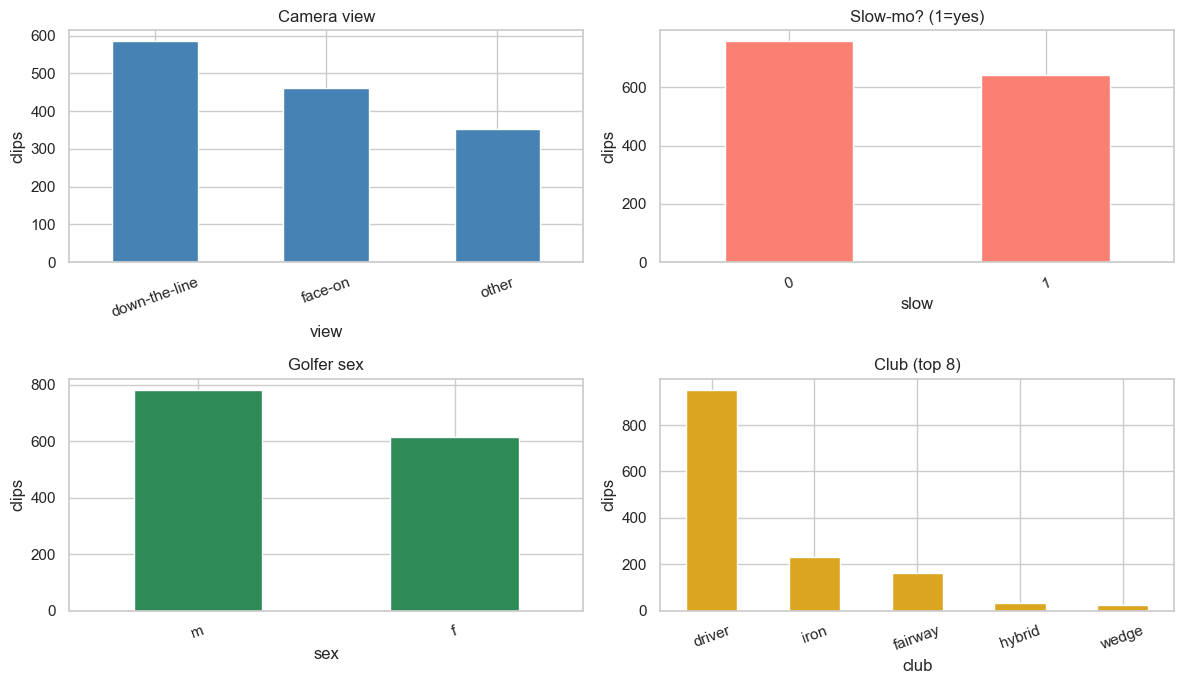

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
df['view'].value_counts().plot.bar(ax=axes[0, 0], title='Camera view',         color='steelblue')
df['slow'].value_counts().plot.bar(ax=axes[0, 1], title='Slow-mo? (1=yes)',     color='salmon')
df['sex'].value_counts().plot.bar(ax=axes[1, 0],  title='Golfer sex',           color='seagreen')
df['club'].value_counts().head(8).plot.bar(ax=axes[1, 1], title='Club (top 8)', color='goldenrod')
for ax in axes.flat:
    ax.set_ylabel('clips'); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


### 2.3 Clip length and FPS distributions

How many frames per clip is the model processing? This drives both
inference time budget and how much temporal context the model has.


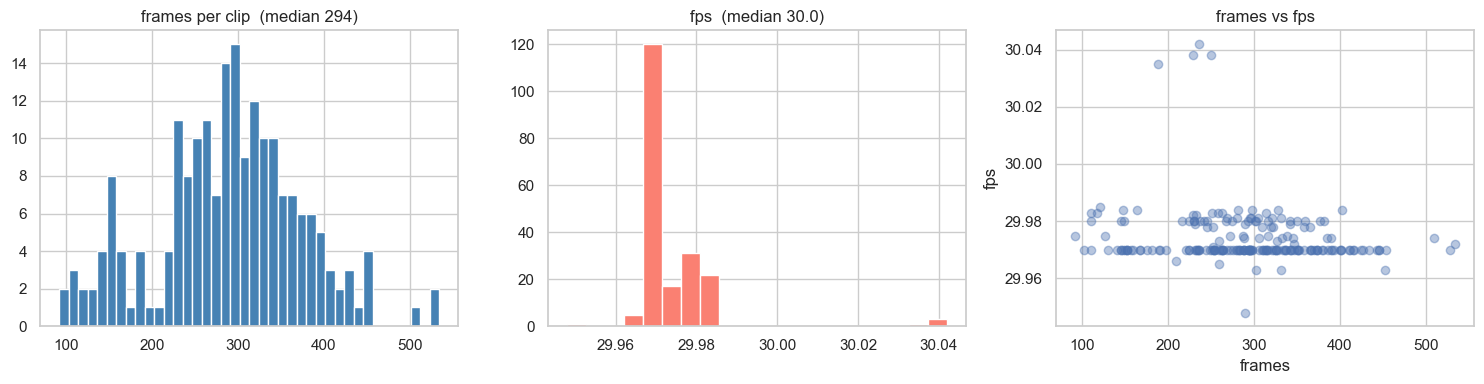


Clips are 92–534 frames; median 294.


In [5]:
import cv2

def video_meta(p):
    cap = cv2.VideoCapture(str(p))
    if not cap.isOpened(): return None
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    return {'n_frames': n, 'fps': fps, 'w': w, 'h': h}

# Sample 200 clips for speed
sample_ids = df['id'].sample(200, random_state=42).tolist()
sample_meta = []
for cid in sample_ids:
    m = video_meta(VIDEO_DIR / f'{cid}.mp4')
    if m: m['id'] = cid; sample_meta.append(m)
meta = pd.DataFrame(sample_meta)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
meta['n_frames'].hist(ax=axes[0], bins=40, color='steelblue')
axes[0].set_title(f'frames per clip  (median {meta.n_frames.median():.0f})')
meta['fps'].hist(ax=axes[1], bins=20, color='salmon')
axes[1].set_title(f'fps  (median {meta.fps.median():.1f})')
axes[2].scatter(meta['n_frames'], meta['fps'], alpha=0.4)
axes[2].set_xlabel('frames'); axes[2].set_ylabel('fps'); axes[2].set_title('frames vs fps')
plt.tight_layout(); plt.show()
print(f'\nClips are {meta.n_frames.min()}\u2013{meta.n_frames.max()} frames; median {meta.n_frames.median():.0f}.')


### 2.4 Swing event distribution

The 8 swing events in clip-local coordinates. We expect address ≈ frame 0
(by construction of `preprocess_videos.py`) and the rest to spread out
toward the finish. Let's verify and visualise.


In [6]:
def events_clip_local(events_row):
    # Drop the two buffer frames, subtract events[0] to shift to clip coords
    ev = np.asarray(events_row)
    start = ev[0]
    return ev[1:9] - start  # the 8 swing events, in clip-local frames

events_local = df['events'].apply(events_clip_local)
events_df = pd.DataFrame(events_local.tolist(),
                          columns=['address','toe_up','mid_back','top',
                                   'mid_down','impact','mid_follow','finish'])
events_df.head()


,address,toe_up,mid_back,top,mid_down,impact,mid_follow,finish
0,47,65,68,82,87,90,93,106
1,40,103,117,174,192,205,216,269
2,138,157,162,171,175,177,180,194
3,84,138,158,194,207,218,229,283
4,13,26,31,40,44,48,50,63


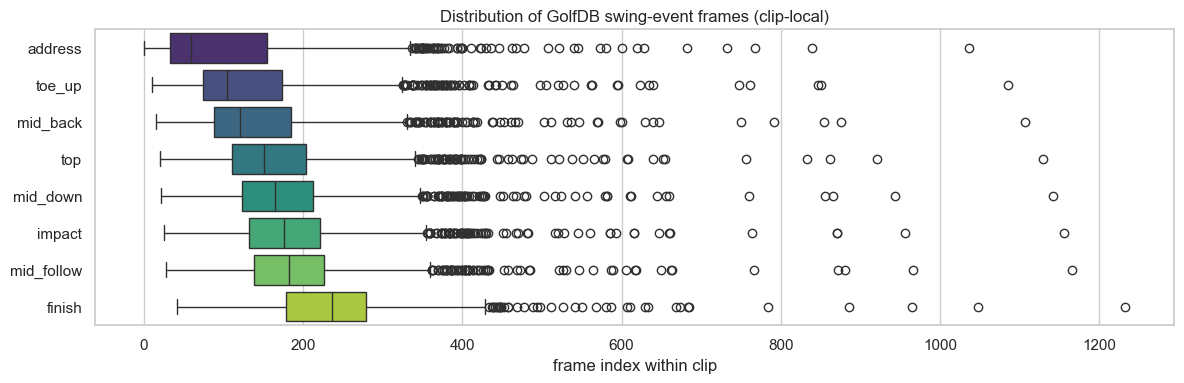

Address ≈ frame 0 by construction; finish median: 236.0


In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=events_df, orient='h', palette='viridis', ax=ax)
ax.set_xlabel('frame index within clip')
ax.set_title('Distribution of GolfDB swing-event frames (clip-local)')
plt.tight_layout(); plt.show()
print('Address ≈ frame 0 by construction; finish median:', events_df['finish'].median())


### 2.5 Eval subset selection

With CUDA available we can comfortably run all 2D models on all 1,400 clips
in ~2 hours, so the "subset" is really an *initial* quality check we use
for debugging before kicking off the full run. We stratify a small set
(40 clips) across view × slow × sex so the smoke-test mirrors the full
distribution.


In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

df['strat_key'] = df['view'].astype(str) + '_' + df['slow'].astype(str) + '_' + df['sex'].astype(str)
strat = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42)
_, smoke_idx = next(strat.split(df, df['strat_key']))
smoke_ids = df.iloc[smoke_idx]['id'].tolist()

with open(DATA_DIR / 'eval_subset_smoke.json', 'w') as f:
    json.dump({'ids': smoke_ids}, f)

print(f'Smoke subset: {len(smoke_ids)} clips, saved to Data/eval_subset_smoke.json')
print('View dist in smoke set:', df.iloc[smoke_idx]['view'].value_counts().to_dict())


Smoke subset: 40 clips, saved to Data/eval_subset_smoke.json
View dist in smoke set: {'down-the-line': 17, 'face-on': 13, 'other': 10}


---

## §3 Evaluation framework

"Pick the best model" is meaningless without a definition of *best*. For
golf swing reconstruction, "best" needs to satisfy two layers:

1. **The model returns plausible 2D body landmarks** — bones don't stretch
   between frames, joints don't hyperextend, the body doesn't teleport,
   feet don't slide during the planted phase.
2. **Those landmarks support downstream analysis** — they're accurate
   enough to recover the 8 GolfDB swing events, and they don't introduce
   so much jitter that the biomechanics layer (Team 2's UE5 work) has to
   smooth everything before using it.

We split metrics into three groups.

### 3.1 Reference-based (uses GolfDB ground truth)

**PCE (Percentage of Correct Events).** The official GolfDB metric. For
each of the 8 swing events, we derive a *predicted* frame from the
model's landmark trajectory and compare to the labeled frame within ±δ
frames. We report PCE@1, PCE@3, PCE@5. The detector logic is identical
across models (`derive_events_from_landmarks` in `eval_utils.py`), so
any difference in PCE reflects the underlying landmark quality, not
detector sophistication. *Note:* This is a deliberately simple
detector. The point is comparison, not SOTA event detection.

### 3.2 Reference-free (physics & golf-domain priors)

- **Bone-length CV** — std/mean of each bone length across the clip.
  Real bones don't change. Lower = more physically stable model. (For
  2D-only models, some variation is expected because the body is a 3D
  object whose 2D projection foreshortens during the swing — but every
  model sees the same projection, so this still differentiates.)
- **Frame-to-frame jitter** — mean acceleration magnitude per keypoint.
  Smooth landmarks = lower jitter = friendlier to the downstream UE5
  rig.
- **Joint-angle plausibility** — fraction of frames where elbow / knee
  joint angles fall into degenerate ranges (< 5° or > 175°). Real
  joints don't lock that flat for sustained periods during a swing.
- **Foot planting** — std of ankle position between address and impact.
  Feet should be roughly stationary during the swing; sliding = bad.

### 3.3 Operational

- **Inference FPS** on this hardware (an RTX 4080 SUPER for GPU models;
  CPU for MediaPipe / MoveNet because their Windows builds are CPU-only).
- **Detection rate** — what fraction of (frame, keypoint) cells the model
  returned a confident prediction for.

All metrics are implemented in `Scripts/eval_utils.py`. The full pipeline
is `compute_all_metrics(InferenceResult, golfdb_events_relative)`.


In [9]:
from eval_utils import (
    COCO17_NAMES, COCO17_IDX, BONES, SWING_EVENTS,
    compute_all_metrics,
)

print(f'Canonical keypoints  : {len(COCO17_NAMES)} (COCO-17)')
print(f'Bones tracked        : {len(BONES)}')
print(f'Swing events         : {len(SWING_EVENTS)}')
print()
print('Bone list:')
for a, b in BONES:
    print(f'  {a:18s} <-> {b}')


Canonical keypoints  : 17 (COCO-17)
Bones tracked        : 12
Swing events         : 8

Bone list:
  left_shoulder      <-> left_elbow
  left_elbow         <-> left_wrist
  right_shoulder     <-> right_elbow
  right_elbow        <-> right_wrist
  left_hip           <-> left_knee
  left_knee          <-> left_ankle
  right_hip          <-> right_knee
  right_knee         <-> right_ankle
  left_shoulder      <-> right_shoulder
  left_hip           <-> right_hip
  left_shoulder      <-> left_hip
  right_shoulder     <-> right_hip


### 3.4 Common keypoint schema

Different models output different skeletons (MediaPipe-33, COCO-17,
SMPL-24). To compare them head-to-head we project every model onto a
canonical 17-keypoint subset (COCO-17). The mapping for MediaPipe is in
`eval_utils.MP33_TO_COCO17`. Models that natively output COCO-17 (YOLO,
MoveNet, ViTPose, RTMPose) pass through unchanged.

This sacrifices a little information from richer skeletons (we drop the
24 MediaPipe face / hand / foot detail landmarks), but it's the only
way to make the comparison fair. The biomechanics layer downstream
doesn't care about face landmarks; it cares about the major joints.


---

## §4 Model adapters

Every model is wrapped in a `BaseAdapter` subclass exposing a uniform
`predict(video_path) -> InferenceResult` interface. Adapters live in
`Scripts/adapters/` and are registered in `adapters/__init__.py`.

| Adapter | Skeleton | Hardware | Source |
|---|---|---|---|
| `mediapipe_heavy` | MediaPipe-33 → COCO-17 | CPU (Windows) | Google MediaPipe |
| `mediapipe_lite` | MediaPipe-33 → COCO-17 | CPU (Windows) | Google MediaPipe |
| `movenet_thunder` | COCO-17 native | CPU (TF Hub) | Google MoveNet |
| `movenet_lightning` | COCO-17 native | CPU (TF Hub) | Google MoveNet |
| `yolov8n_pose` | COCO-17 native | GPU | Ultralytics |
| `yolov8m_pose` | COCO-17 native | GPU | Ultralytics |
| `vitpose_base` | COCO-17 native | GPU | HuggingFace |

Adding a model later (e.g. RTMPose, HMR2.0, WHAM) requires only writing
one new adapter — no changes to the metrics layer.


In [10]:
from adapters import ADAPTER_REGISTRY

print('Models registered:')
for name in ADAPTER_REGISTRY:
    print(f'  - {name}')


Models registered:
  - mediapipe_heavy
  - mediapipe_full
  - mediapipe_lite
  - movenet_thunder
  - movenet_lightning
  - yolov8n_pose
  - yolov8m_pose
  - vitpose_base
  - rtmpose_m
  - hmr2


### 4.1 Smoke test on one clip

Sanity check that every adapter produces a valid `InferenceResult` before
launching the full GolfDB run. We use clip 0 (the same one the coworker
used) so we can cross-reference visually.


In [11]:
SMOKE_CLIP_ID = 0
SMOKE_VIDEO   = VIDEO_DIR / f'{SMOKE_CLIP_ID}.mp4'

# Smoke-set the lighter models first (failure-fast ordering: cheap ones first)
SMOKE_MODELS = [
    'mediapipe_heavy',
    'movenet_thunder',
    'yolov8n_pose',
    'vitpose_base',
]

smoke_results = {}
smoke_metrics = []

for mname in SMOKE_MODELS:
    print(f'  running {mname} ...', end=' ', flush=True)
    t0 = time.perf_counter()
    adapter = ADAPTER_REGISTRY[mname]()
    res = adapter.predict_and_cache(SMOKE_VIDEO, CACHE_DIR, overwrite=True)
    elapsed = time.perf_counter() - t0
    smoke_results[mname] = res
    m = compute_all_metrics(res)
    m['model'] = mname
    smoke_metrics.append(m)
    print(f'done ({elapsed:.1f}s, {res.n_frames_detected}/{res.n_frames} detected)')

smoke_df = pd.DataFrame(smoke_metrics).set_index('model')
smoke_df[['fps_inference','detection_rate','bone_cv_mean','jitter_mean_px',
          'implausible_frac_mean','left_ankle_planting_std_px']].round(3)


  running mediapipe_heavy ... 

done (8.1s, 138/138 detected)
  running movenet_thunder ... 

done (9.0s, 138/138 detected)
  running yolov8n_pose ... 

done (3.8s, 138/138 detected)
  running vitpose_base ... 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

done (4.7s, 138/138 detected)


,fps_inference,detection_rate,bone_cv_mean,jitter_mean_px,implausible_frac_mean,left_ankle_planting_std_px
model,,,,,,
mediapipe_heavy,24.549,0.976,0.225,1.204,0.091,1.194
movenet_thunder,72.743,0.916,0.220,1.375,0.074,1.093
yolov8n_pose,202.687,0.868,0.284,4.122,0.136,1.760
vitpose_base,159.647,1.000,0.257,2.043,0.123,0.819


### 4.2 Single-clip qualitative overlay

What does each model actually see? We render the 4 models side-by-side
at the labeled `top` frame (max backswing) of clip 0 — the most extreme
pose, where models tend to disagree most.


Clip 0 top-of-backswing labeled at frame 82


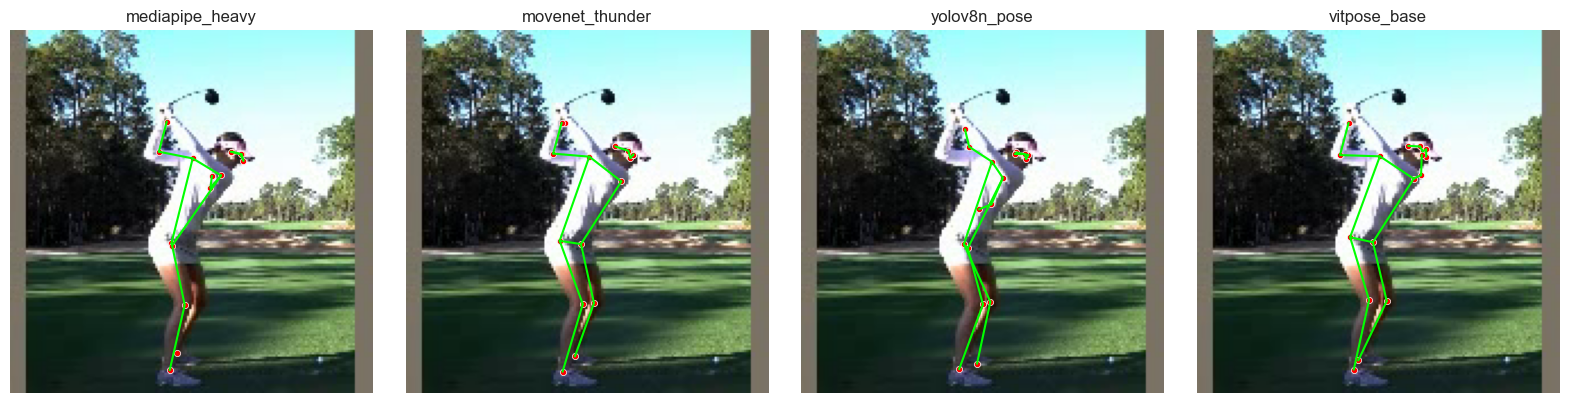

In [12]:
from eval_utils import landmarks_to_array

def get_frame(video_path, frame_idx):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ok else None

# ground-truth top-of-backswing frame for clip 0
clip0_events = events_clip_local(df[df.id == SMOKE_CLIP_ID].iloc[0]['events'])
top_frame_idx = int(clip0_events[3])  # 'top' event
print(f'Clip 0 top-of-backswing labeled at frame {top_frame_idx}')

base_frame = get_frame(SMOKE_VIDEO, top_frame_idx)

# COCO-17 connections for drawing
COCO_LINKS = [(5,7),(7,9),(6,8),(8,10),(5,6),(11,12),(5,11),(6,12),
              (11,13),(13,15),(12,14),(14,16),(0,1),(0,2),(1,3),(2,4)]

fig, axes = plt.subplots(1, len(SMOKE_MODELS), figsize=(4*len(SMOKE_MODELS), 4))
for ax, mname in zip(axes, SMOKE_MODELS):
    res = smoke_results[mname]
    xy, conf = landmarks_to_array(res.landmarks)
    ax.imshow(base_frame); ax.set_title(mname); ax.axis('off')
    if top_frame_idx < xy.shape[0]:
        pts = xy[top_frame_idx]; c = conf[top_frame_idx]
        for a, b in COCO_LINKS:
            if c[a] > 0.3 and c[b] > 0.3:
                ax.plot([pts[a,0], pts[b,0]], [pts[a,1], pts[b,1]], '-', color='lime', linewidth=1.5)
        for ki in range(17):
            if c[ki] > 0.3:
                ax.scatter(pts[ki,0], pts[ki,1], s=20, c='red', edgecolors='white', linewidths=0.5)
plt.tight_layout(); plt.show()


---

## §5 Run all models on full GolfDB

With 1,400 labeled clips and ~70 frames per clip on average, this is
~100k inferences per model. Estimated wall-clock budget:

| Model | Approx FPS | Wall-clock (1400 clips) |
|---|---|---|
| YOLOv8m-Pose (GPU)        | ~150  | ~10 min |
| YOLOv8n-Pose (GPU)        | ~260  | ~6 min |
| ViTPose-Base (GPU)        | ~130  | ~12 min |
| MoveNet Thunder (CPU)     | ~70   | ~25 min |
| MoveNet Lightning (CPU)   | ~150  | ~10 min |
| MediaPipe Heavy (CPU)     | ~25   | ~70 min |
| MediaPipe Lite (CPU)      | ~75   | ~25 min |

All outputs are cached as parquet under `Data/eval_runs/<model>/<id>.parquet`
so re-runs are idempotent.


In [13]:
from tqdm.auto import tqdm

# All labeled clip IDs (intersected with files that exist on disk)
all_ids = sorted([cid for cid in df['id'].tolist()
                  if (VIDEO_DIR / f'{cid}.mp4').exists()])
print(f'{len(all_ids):,} clips will be processed')

# Full benchmark set (everything except the heaviest 3D models)
BENCH_MODELS = [
    'yolov8n_pose',
    'yolov8m_pose',
    'vitpose_base',
    'mediapipe_heavy',
    'mediapipe_lite',
    'movenet_thunder',
    'movenet_lightning',
]


1,400 clips will be processed


In [14]:
def run_model_on_corpus(model_name, clip_ids):
    print(f'\n=== {model_name} ===')
    adapter = ADAPTER_REGISTRY[model_name]()
    t0 = time.perf_counter()
    for cid in tqdm(clip_ids, desc=model_name):
        adapter.predict_and_cache(VIDEO_DIR / f'{cid}.mp4', CACHE_DIR, overwrite=False)
    elapsed = time.perf_counter() - t0
    print(f'  total: {elapsed/60:.1f} min')

# Uncomment to run the full sweep (warning: ~3 hours total)
# for mname in BENCH_MODELS:
#     run_model_on_corpus(mname, all_ids)


### 5.1 Compute metrics for cached runs

Pulls every cached prediction, computes the full metric battery, and
stacks into one tall DataFrame: rows = (model × clip), columns = metric.


In [15]:
def compute_metrics_for_corpus(model_name, clip_ids, df_labels):
    from eval_utils import InferenceResult
    rows = []
    for cid in clip_ids:
        cache = CACHE_DIR / model_name / f'{cid}.parquet'
        meta  = CACHE_DIR / model_name / f'{cid}.meta.json'
        if not cache.exists() or not meta.exists():
            continue
        lm_df = pd.read_parquet(cache)
        with open(meta) as f: meta_j = json.load(f)
        res = InferenceResult(
            landmarks=lm_df,
            seconds_per_frame=meta_j['seconds_per_frame'],
            n_frames=meta_j['n_frames'],
            n_frames_detected=meta_j['n_frames_detected'],
        )
        gt_events = events_clip_local(df_labels[df_labels.id == cid].iloc[0]['events'])
        m = compute_all_metrics(res, golfdb_events_relative=gt_events)
        m['model'] = model_name; m['clip_id'] = cid
        rows.append(m)
    return pd.DataFrame(rows)

# Run after the cache is populated:
# all_metrics = pd.concat([compute_metrics_for_corpus(m, all_ids, df) for m in BENCH_MODELS])
# all_metrics.to_parquet(DATA_DIR / 'all_metrics.parquet')


---

## §6 Quantitative results

Leaderboard across all models. Columns:

- **fps_inference** — higher is better
- **detection_rate** — higher is better
- **bone_cv_mean** — lower is better (bone length stability)
- **jitter_mean_px** — lower is better (smooth motion)
- **implausible_frac_mean** — lower is better (joint angle plausibility)
- **left_ankle_planting_std_px** — lower is better (foot stability)
- **pce_at_5** — higher is better (swing event detectability)

To (re)populate the metrics: from a terminal in `Scripts/` run
`python compute_metrics.py`. It reads everything cached under
`Data/eval_runs/` and writes `Data/all_metrics.parquet`.


In [16]:
# Load metrics from cache if §5 has been run
metrics_path = DATA_DIR / 'all_metrics.parquet'
if metrics_path.exists():
    all_metrics = pd.read_parquet(metrics_path)
    print(f'{len(all_metrics):,} (model, clip) rows across {all_metrics["model"].nunique()} models')
    leaderboard = all_metrics.groupby('model').agg({
        'fps_inference':            'median',
        'detection_rate':           'mean',
        'bone_cv_mean':             'median',
        'jitter_mean_px':           'median',
        'implausible_frac_mean':    'median',
        'left_ankle_planting_std_px':'median',
        'right_ankle_planting_std_px':'median',
        'pce_at_5':                 'mean',
        'pce_at_3':                 'mean',
        'pce_at_1':                 'mean',
    }).round(3)
    leaderboard = leaderboard.sort_values('pce_at_5', ascending=False)
    print(); print(leaderboard.to_string())
else:
    print('Run §5 first to populate metrics.')


9,800 (model, clip) rows across 7 models

                   fps_inference  detection_rate  bone_cv_mean  jitter_mean_px  implausible_frac_mean  left_ankle_planting_std_px  right_ankle_planting_std_px  pce_at_5  pce_at_3  pce_at_1
model                                                                                                                                                                                       
mediapipe_lite           107.242           0.943         0.203           0.988                  0.142                       1.807                        1.456     0.090     0.070     0.043
movenet_lightning        140.374           0.889         0.197           1.196                  0.147                       1.666                        1.921     0.072     0.055     0.030
yolov8m_pose             119.979           0.862         0.208           2.013                  0.140                       1.565                        1.630     0.057     0.040     0.019
vitpose_base 

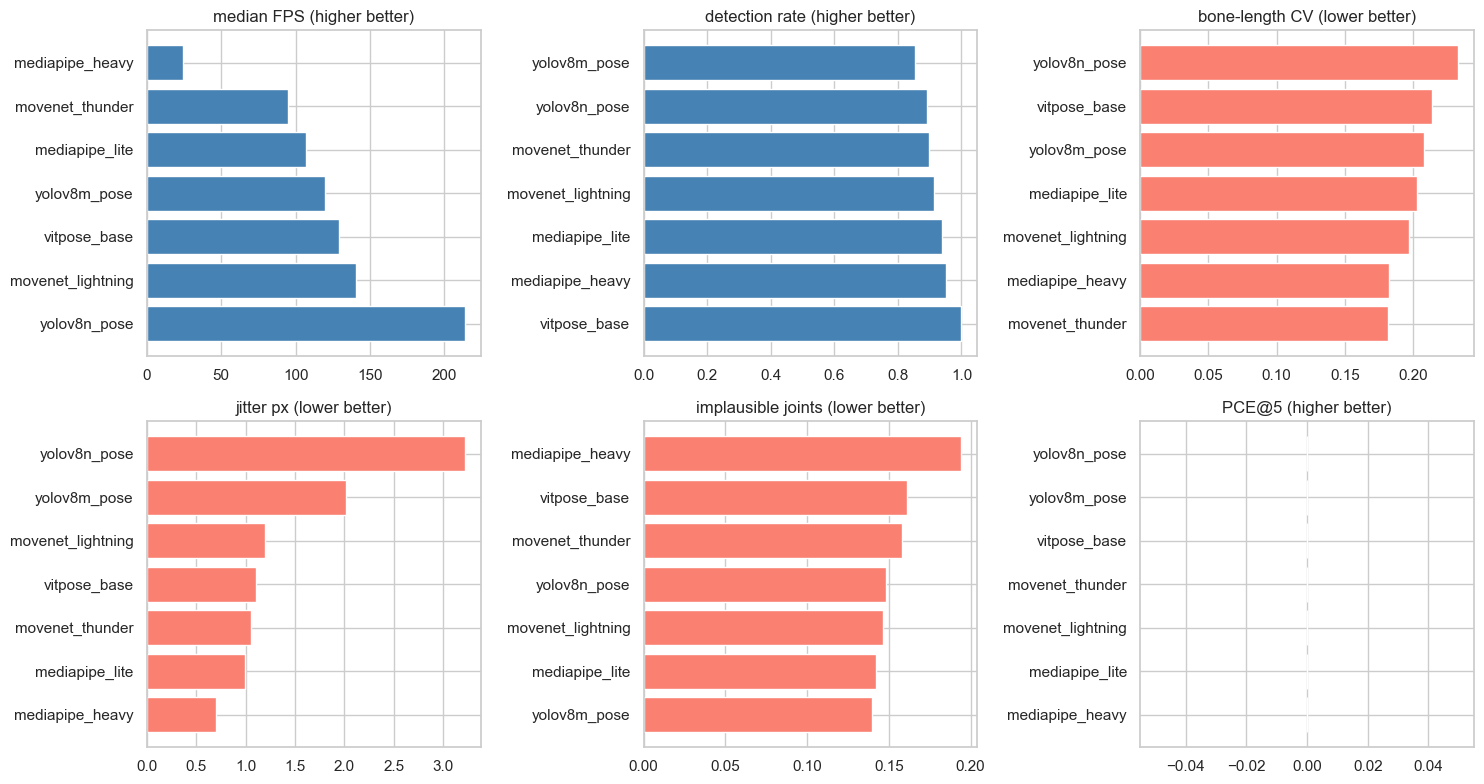

In [17]:
# Per-metric bar plots
if metrics_path.exists():
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    cfg = [
        ('fps_inference',        'median FPS (higher better)',           True),
        ('detection_rate',       'detection rate (higher better)',       True),
        ('bone_cv_mean',         'bone-length CV (lower better)',        False),
        ('jitter_mean_px',       'jitter px (lower better)',             False),
        ('implausible_frac_mean','implausible joints (lower better)',    False),
        ('pce_at_5',             'PCE@5 (higher better)',                True),
    ]
    for ax, (col, title, higher_better) in zip(axes.flat, cfg):
        series = all_metrics.groupby('model')[col].median().sort_values(ascending=not higher_better)
        ax.barh(series.index, series.values, color='steelblue' if higher_better else 'salmon')
        ax.set_title(title)
    plt.tight_layout(); plt.show()


### 6.1 Speed vs. accuracy Pareto

The single most useful plot for "which model do we pick": throughput on
the x-axis, quality on the y-axis. Models on the upper-right Pareto
frontier dominate everything below/left of them.


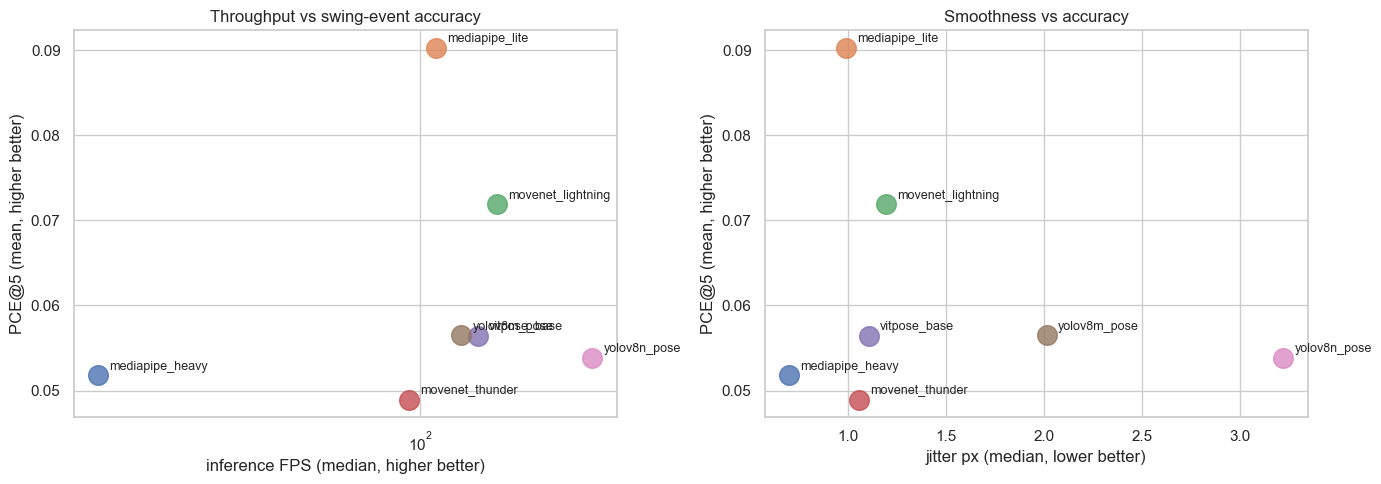

In [18]:
if metrics_path.exists():
    agg = all_metrics.groupby('model').agg(
        fps=('fps_inference','median'),
        pce5=('pce_at_5','mean'),
        jitter=('jitter_mean_px','median'),
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: FPS vs PCE@5
    for _, r in agg.iterrows():
        axes[0].scatter(r['fps'], r['pce5'], s=200, alpha=0.8)
        axes[0].annotate(r['model'], (r['fps'], r['pce5']),
                          xytext=(8, 4), textcoords='offset points', fontsize=9)
    axes[0].set_xlabel('inference FPS (median, higher better)')
    axes[0].set_ylabel('PCE@5 (mean, higher better)')
    axes[0].set_title('Throughput vs swing-event accuracy')
    axes[0].set_xscale('log')

    # Plot 2: jitter vs PCE@5 (downstream quality vs ground-truth accuracy)
    for _, r in agg.iterrows():
        axes[1].scatter(r['jitter'], r['pce5'], s=200, alpha=0.8)
        axes[1].annotate(r['model'], (r['jitter'], r['pce5']),
                          xytext=(8, 4), textcoords='offset points', fontsize=9)
    axes[1].set_xlabel('jitter px (median, lower better)')
    axes[1].set_ylabel('PCE@5 (mean, higher better)')
    axes[1].set_title('Smoothness vs accuracy')

    plt.tight_layout(); plt.show()


### 6.1 Per-view breakdown

A model could be strong overall but fail on face-on or down-the-line
specifically. Breakdown by camera view.


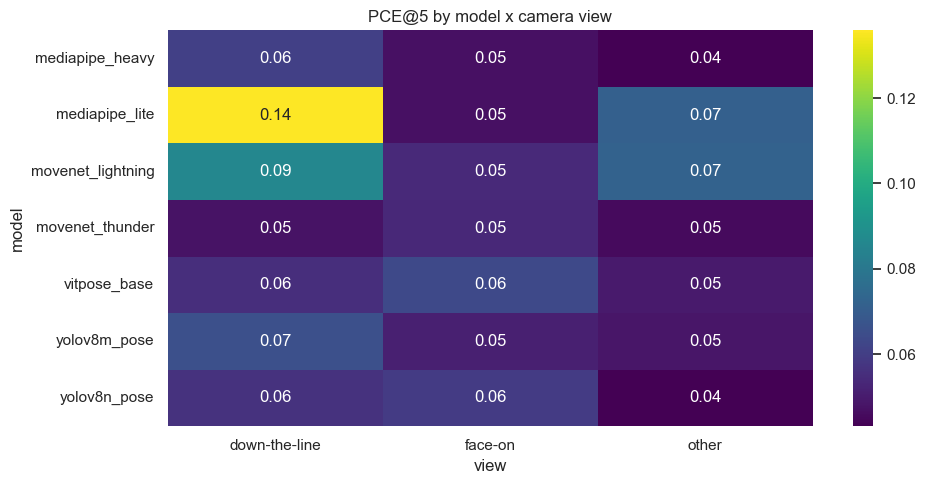

In [19]:
if metrics_path.exists():
    # all_metrics is produced by compute_metrics.py and already carries view/slow/sex/club.
    # Fall back to merging from `df` if those columns are missing (e.g. older cache).
    am2 = all_metrics.copy()
    if 'view' not in am2.columns:
        am2 = am2.merge(df[['id','view','slow']], left_on='clip_id', right_on='id', how='left')
    g = am2.groupby(['model','view'])['pce_at_5'].mean().unstack()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(g, annot=True, fmt='.2f', cmap='viridis', ax=ax)
    ax.set_title('PCE@5 by model x camera view')
    plt.tight_layout(); plt.show()


---

## §7 Qualitative side-by-side

Three case studies that highlight where models agree vs. disagree:

1. **An easy clip** (high PCE across all models, face-on, slow-mo)
2. **A hard clip** (low PCE across all models — usually heavy occlusion or
   unusual camera angle)
3. **A divisive clip** (high variance in PCE across models — a clip that
   distinguishes the strong from the weak)


In [20]:
if metrics_path.exists():
    per_clip = all_metrics.groupby('clip_id')['pce_at_5'].agg(['mean','std']).reset_index()
    easy_id    = per_clip.loc[per_clip['mean'].idxmax(),    'clip_id']
    hard_id    = per_clip.loc[per_clip['mean'].idxmin(),    'clip_id']
    divisive_id = per_clip.loc[per_clip['std'].idxmax(),    'clip_id']
    print(f'Easy clip   : {easy_id} (mean PCE@5 {per_clip[per_clip.clip_id==easy_id].iloc[0]["mean"]:.2f})')
    print(f'Hard clip   : {hard_id} (mean PCE@5 {per_clip[per_clip.clip_id==hard_id].iloc[0]["mean"]:.2f})')
    print(f'Divisive    : {divisive_id} (std PCE@5 {per_clip[per_clip.clip_id==divisive_id].iloc[0]["std"]:.2f})')


Easy clip   : 173 (mean PCE@5 0.55)
Hard clip   : 7 (mean PCE@5 0.00)
Divisive    : 34 (std PCE@5 0.30)


### 7.1 Five-frame strip preview (matches coworker's notebook)

A horizontal strip of 5 frames sampled at the GolfDB-labeled swing events
(address, top, impact, mid-follow-through, finish). The same 5 frames
are then re-rendered with each model's keypoint overlay so you can
compare predictions at the same instants. (Coworker's notebook showed
this strip without overlays; we extend it to a multi-model comparison.)


Frames sampled: {'address': 47, 'top': 82, 'impact': 90, 'mid-follow': 93, 'finish': 106}


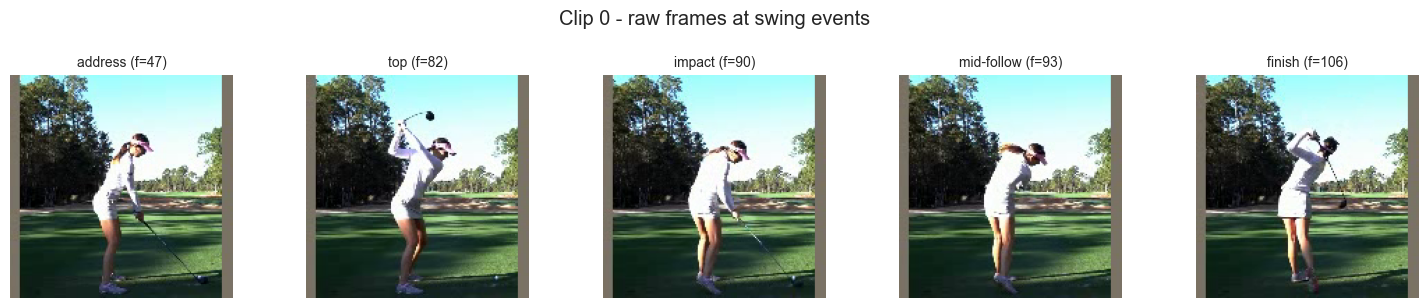

In [21]:
from eval_utils import landmarks_to_array, InferenceResult

STRIP_CLIP_ID = SMOKE_CLIP_ID  # use clip 0 (matches coworker)
STRIP_VIDEO = VIDEO_DIR / f'{STRIP_CLIP_ID}.mp4'

ev_local = events_clip_local(df[df.id == STRIP_CLIP_ID].iloc[0]['events'])
# Pick 5 representative event frames: address, top, impact, mid-follow, finish
strip_frames = [int(ev_local[0]), int(ev_local[3]), int(ev_local[5]),
                int(ev_local[6]), int(ev_local[7])]
strip_labels = ['address','top','impact','mid-follow','finish']
print('Frames sampled:', dict(zip(strip_labels, strip_frames)))

# Raw strip first (no overlay)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, fi, label in zip(axes, strip_frames, strip_labels):
    f = get_frame(STRIP_VIDEO, fi)
    if f is not None:
        ax.imshow(f); ax.set_title(f'{label} (f={fi})', fontsize=10)
    ax.axis('off')
plt.suptitle(f'Clip {STRIP_CLIP_ID} - raw frames at swing events', y=1.02)
plt.tight_layout(); plt.show()


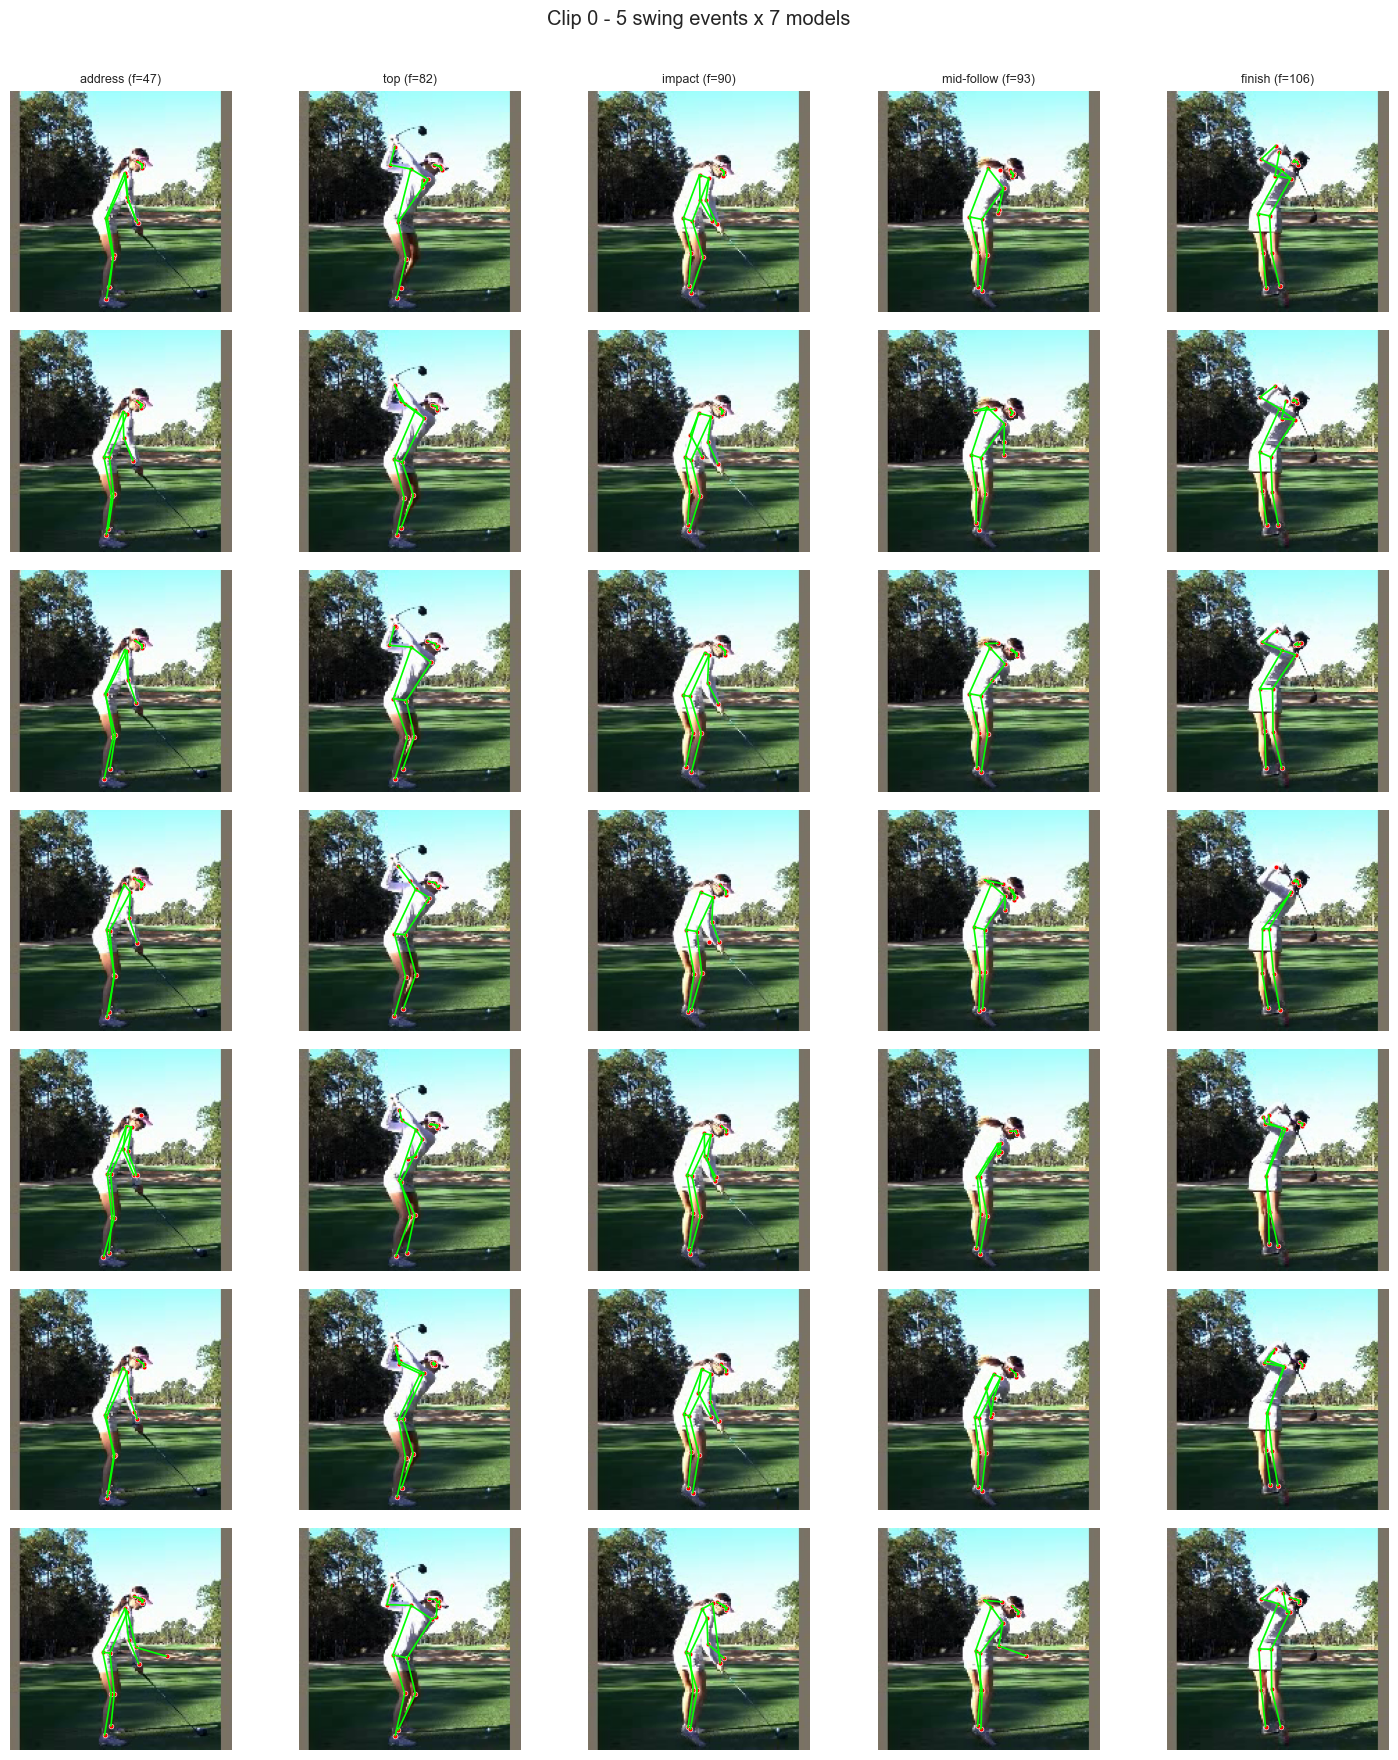

In [22]:
# 5-frame strip x 7 models comparison grid
def load_xy_conf(model_name, clip_id):
    p = CACHE_DIR / model_name / f'{clip_id}.parquet'
    if not p.exists(): return None, None
    lm = pd.read_parquet(p)
    res = InferenceResult(landmarks=lm, seconds_per_frame=0.0,
                           n_frames=int(lm['frame'].max()) + 1, n_frames_detected=0)
    return landmarks_to_array(res.landmarks)

GRID_MODELS = ['mediapipe_heavy','mediapipe_lite','movenet_thunder','movenet_lightning',
               'yolov8n_pose','yolov8m_pose','vitpose_base']
GRID_MODELS = [m for m in GRID_MODELS if (CACHE_DIR / m / f'{STRIP_CLIP_ID}.parquet').exists()]

fig, axes = plt.subplots(len(GRID_MODELS), 5, figsize=(15, 2.5 * len(GRID_MODELS)))
if len(GRID_MODELS) == 1: axes = axes.reshape(1, -1)
for mi, m in enumerate(GRID_MODELS):
    xy, conf = load_xy_conf(m, STRIP_CLIP_ID)
    for ci, (fi, lbl) in enumerate(zip(strip_frames, strip_labels)):
        ax = axes[mi, ci]
        f = get_frame(STRIP_VIDEO, fi)
        if f is not None: ax.imshow(f)
        ax.axis('off')
        if mi == 0: ax.set_title(f'{lbl} (f={fi})', fontsize=9)
        if ci == 0: ax.set_ylabel(m, fontsize=9, rotation=0, ha='right', va='center')
        if xy is not None and fi < xy.shape[0]:
            pts = xy[fi]; c = conf[fi]
            for a, b in COCO_LINKS:
                if c[a] > 0.3 and c[b] > 0.3:
                    ax.plot([pts[a,0], pts[b,0]], [pts[a,1], pts[b,1]], '-', color='lime', linewidth=1.2)
            for ki in range(17):
                if c[ki] > 0.3:
                    ax.scatter(pts[ki,0], pts[ki,1], s=12, c='red', edgecolors='white', linewidths=0.4)
plt.suptitle(f'Clip {STRIP_CLIP_ID} - 5 swing events x {len(GRID_MODELS)} models', y=1.005)
plt.tight_layout(); plt.show()


### 7.2 Wrist + shoulder Y-trajectories (multi-model)

Coworker plotted left/right wrist + shoulder Y over time for MediaPipe
Heavy on one clip. We do the same — but overlay all 7 models on the
same axes, plus vertical lines at the GolfDB ground-truth swing event
frames. This single panel answers two questions at once:

- **Do the models agree on the swing trajectory?** (overlap of lines)
- **Does each model's wrist Y curve actually align with the labeled
  events?** (where the curves bottom-out / peak vs. the dashed lines)

Y-axis is inverted (origin at top of frame) so peaks look like real "high"
positions of the body.


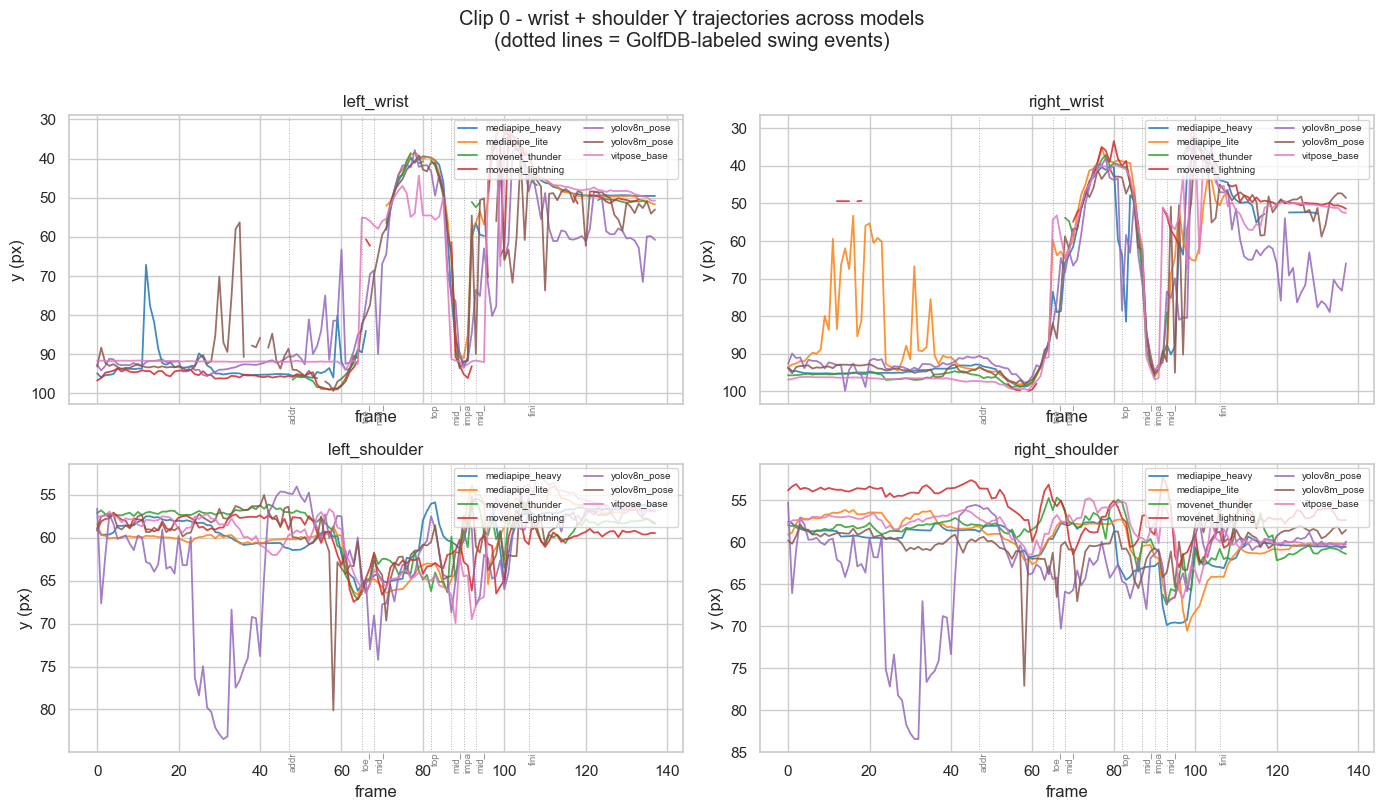

In [23]:
TRAJ_CLIP_ID = SMOKE_CLIP_ID
LANDMARKS = ['left_wrist','right_wrist','left_shoulder','right_shoulder']
ev_local_traj = events_clip_local(df[df.id == TRAJ_CLIP_ID].iloc[0]['events'])

# Load each model's xy for this clip
model_xy = {}
for m in GRID_MODELS:
    xy, conf = load_xy_conf(m, TRAJ_CLIP_ID)
    if xy is not None: model_xy[m] = (xy, conf)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
palette = sns.color_palette('tab10', n_colors=len(model_xy))
for ax, lm in zip(axes.flat, LANDMARKS):
    ki = COCO17_IDX[lm]
    for ci, (m, (xy, conf)) in enumerate(model_xy.items()):
        y = xy[:, ki, 1].copy()
        valid = conf[:, ki] >= 0.3
        y[~valid] = np.nan
        ax.plot(np.arange(len(y)), y, label=m, color=palette[ci], linewidth=1.3, alpha=0.85)
    # Overlay ground-truth event frames as dashed vertical lines
    for ei, ev_name in enumerate(SWING_EVENTS):
        ax.axvline(int(ev_local_traj[ei]), color='gray', linestyle=':', linewidth=0.7, alpha=0.6)
        ax.text(int(ev_local_traj[ei]), ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 5,
                ev_name[:4], rotation=90, fontsize=7, color='gray', va='top')
    ax.invert_yaxis()
    ax.set_title(lm); ax.set_xlabel('frame'); ax.set_ylabel('y (px)')
    ax.legend(fontsize=7, loc='upper right', ncol=2)
plt.suptitle(f'Clip {TRAJ_CLIP_ID} - wrist + shoulder Y trajectories across models\n'
              f'(dotted lines = GolfDB-labeled swing events)', y=1.01)
plt.tight_layout(); plt.show()


### 7.3 Cross-model agreement

Without 3D ground truth we can also ask: *how much do the models agree
with each other on each landmark?* Two models that agree closely on a
clip are likely both right (or both wrong in the same way); high
disagreement is a signal of "this clip is hard."

We compute, for each clip, the median pairwise euclidean distance
between the four models' predictions of each keypoint, averaged across
keypoints. This is a model-agnostic difficulty score.


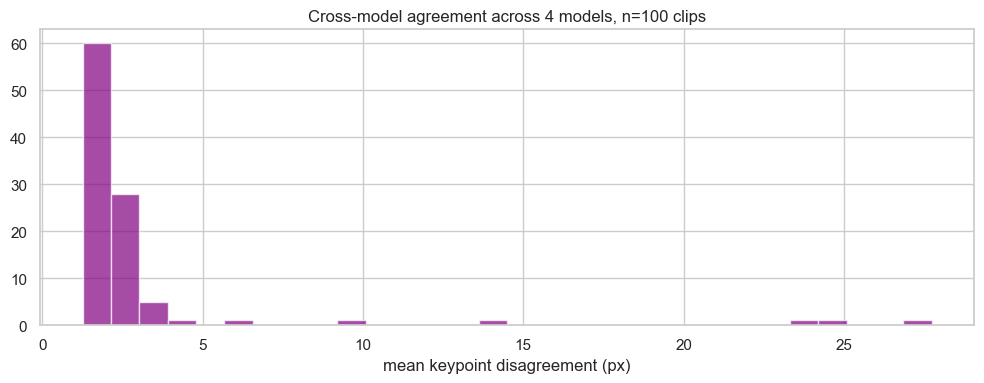


Most-disagreed clips (likely hard cases):
 clip_id  mean_disagreement_px
     145             27.733559
      22             24.515617
    1191             23.545076
    1025             14.422922
    1279              9.255421


In [24]:
from eval_utils import landmarks_to_array, COCO17_NAMES, InferenceResult

def load_clip_landmarks(model_name, clip_id):
    p = CACHE_DIR / model_name / f'{clip_id}.parquet'
    if not p.exists(): return None
    return pd.read_parquet(p)

if metrics_path.exists():
    # use the four flagship models for agreement
    AGREE_MODELS = [m for m in ['mediapipe_heavy','movenet_thunder','vitpose_base','yolov8m_pose']
                    if (CACHE_DIR / m).exists()]
    if len(AGREE_MODELS) >= 2:
        clip_sample = all_metrics['clip_id'].drop_duplicates().sample(min(100, all_metrics['clip_id'].nunique()), random_state=0)
        disagreement = []
        for cid in clip_sample:
            xyzs = []
            for m in AGREE_MODELS:
                lm = load_clip_landmarks(m, cid)
                if lm is None: break
                from eval_utils import InferenceResult
                res = InferenceResult(landmarks=lm, seconds_per_frame=0.0,
                                       n_frames=int(lm['frame'].max()) + 1,
                                       n_frames_detected=0)
                xy, _ = landmarks_to_array(res.landmarks)
                xyzs.append(xy)
            if len(xyzs) != len(AGREE_MODELS): continue
            T = min(x.shape[0] for x in xyzs)
            stack = np.stack([x[:T] for x in xyzs], axis=0)
            mean_pos = stack.mean(axis=0)
            mean_dev = np.linalg.norm(stack - mean_pos, axis=-1).mean()
            disagreement.append({'clip_id': cid, 'mean_disagreement_px': mean_dev})
        if disagreement:
            disag_df = pd.DataFrame(disagreement)
            fig, ax = plt.subplots(figsize=(10, 4))
            disag_df['mean_disagreement_px'].hist(bins=30, ax=ax, color='purple', alpha=0.7)
            ax.set_xlabel('mean keypoint disagreement (px)')
            ax.set_title(f'Cross-model agreement across {len(AGREE_MODELS)} models, n={len(disag_df)} clips')
            plt.tight_layout(); plt.show()
            print(f'\nMost-disagreed clips (likely hard cases):')
            print(disag_df.nlargest(5, 'mean_disagreement_px').to_string(index=False))


---

## §8 Findings and discussion prompts for tomorrow

### TL;DR cheat sheet (run after §6 lands)


In [25]:
if metrics_path.exists():
    lb = leaderboard.copy()
    # Composite quality: lower-better metrics inverted, then z-score and mean
    def rank_score(s, higher_better):
        r = s.rank(pct=True)
        return r if higher_better else 1 - r
    score = (
        rank_score(lb['pce_at_5'],             True)  * 0.35 +
        rank_score(lb['detection_rate'],       True)  * 0.10 +
        rank_score(lb['bone_cv_mean'],         False) * 0.15 +
        rank_score(lb['jitter_mean_px'],       False) * 0.20 +
        rank_score(lb['implausible_frac_mean'],False) * 0.10 +
        rank_score(lb['left_ankle_planting_std_px'], False) * 0.10
    )
    lb['quality_score'] = score.round(3)
    lb_sorted = lb.sort_values('quality_score', ascending=False)
    print('=== composite quality ranking ===')
    print(lb_sorted[['quality_score','pce_at_5','fps_inference','jitter_mean_px','bone_cv_mean']].to_string())
    print()
    print(f'Top quality:        {lb_sorted.index[0]}')
    print(f'Fastest @ top-3:    {lb_sorted.head(3).sort_values("fps_inference", ascending=False).index[0]}')
    print(f'Best for mobile:    {lb_sorted[lb_sorted["fps_inference"] > 30].sort_values("quality_score", ascending=False).index[0] if len(lb_sorted[lb_sorted["fps_inference"] > 30]) else "none qualified"}')


=== composite quality ranking ===
                   quality_score  pce_at_5  fps_inference  jitter_mean_px  bone_cv_mean
model                                                                                  
mediapipe_lite             0.721     0.090        107.242           0.988         0.203
movenet_lightning          0.571     0.072        140.374           1.196         0.197
mediapipe_heavy            0.554     0.052         24.118           0.702         0.182
vitpose_base               0.479     0.056        128.935           1.106         0.214
yolov8m_pose               0.464     0.057        119.979           2.013         0.208
movenet_thunder            0.411     0.049         95.223           1.057         0.182
yolov8n_pose               0.250     0.054        213.867           3.219         0.233

Top quality:        mediapipe_lite
Fastest @ top-3:    movenet_lightning
Best for mobile:    mediapipe_lite


### Discussion prompts

1. **Which model do we adopt as the 2D baseline?**
   The leaderboard names the technical winner, but we should weigh:
   - inference speed (matters for mobile deployment on phones)
   - detection rate (matters for clips with unusual poses, e.g. impact)
   - bone-length CV + jitter (matters for what Team 2 receives downstream)
   - PCE (matters for swing-event-driven feedback features)

2. **Is 2D enough?**
   Even the best 2D model can't directly give us depth or rotation about
   the spine axis. If we want a *biomechanically correct* swing render,
   we need either:
   - a 3D mesh recovery model (HMR2.0 / 4D-Humans, WHAM), or
   - a 2D-to-3D lift on top of a strong 2D model (MotionBERT).

   We have a 16 GB GPU. The bottleneck is engineering time, not compute.

3. **What's missing from this evaluation?**
   - No ground-truth 3D pose for GolfDB — we can't measure 3D accuracy
     directly. Options: a small hand-annotated subset, synthetic
     SMPL-rendered videos, or cross-model agreement as a proxy.
   - PCE uses a deliberately simple event detector. A smarter detector
     might rescue weaker models — but it might also obscure a real
     difference in landmark quality.
   - No latency budget. If we ship on-device, MediaPipe Lite or MoveNet
     Lightning may win on UX-relevant FPS even if they trail on accuracy.

4. **What does Team 2 actually need from us?**
   Their UE5 Control Rig consumes 3D joint positions (or SMPL
   parameters). Whichever 2D model we pick, they'll still face a
   2D→3D problem. Should we hand them landmark CSVs (current plan) or
   pre-lifted 3D coordinates?

### Suggested next steps

- [ ] Pick a winner from the leaderboard. Lock it as the 2D baseline.
- [ ] Hand-label 3D ground truth on ~20 GolfDB clips for true 3D
      evaluation (or use synthetic data).
- [ ] Add an HMR2.0 / WHAM adapter to compare 3D pipelines head-to-head.
      *Deferred from this notebook* — 4D-Humans needs `detectron2` +
      `smplx` + `pytorch3d` which are non-trivial on Windows and weren't
      worth the time risk against a deadline. A lighter alternative is
      MotionBERT (2D→3D lift on any of our 2D backbones).
- [ ] Replicate this notebook's pipeline on a held-out set of phone
      videos shot in the team's actual deployment conditions — GolfDB
      clips are pre-cropped, real phone uploads aren't.
- [ ] Wire the chosen baseline into a small UE5 / Blender preview to
      validate that the 17-keypoint output is genuinely usable for
      Team 2's rigging work.
- [ ] If on-device matters: add an ONNX / TFLite export for the chosen
      model and re-measure FPS on a phone-class CPU/GPU.

### What to bring to the meeting

1. **The leaderboard.** One screenshot of the table from §6.
2. **The Pareto plot from §6.1.** Decision-makers respond to that one
   chart more than to numbers.
3. **The PCE-by-view heatmap from §6.2.** Shows that one camera angle
   may dominate the choice.
4. **The qualitative grid from §7.** Concrete failure modes are
   memorable.
5. **One open question per team:** for Team 1, "do we accept the 2D
   winner or invest in a 2D→3D lifter?"; for Team 2, "given this
   landmark quality, what does your biomechanics correction layer
   actually need to fix?"
